# Entendimento do negócio


In [51]:
# Importações
import ee
import requests
import re
import os
import urllib3
import zipfile
import shutil
import json
import gc

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

from glob import glob
from io import BytesIO
from shapely.geometry import box

print("OK")

OK


In [52]:
# Roda o comando no terminal : earthengine authenticate --auth_mode=notebook
ee.Authenticate()
ee.Initialize(project="spatial-yew-490017-r3")
print(ee.String("Hello from the Earth Engine servers!").getInfo())

Hello from the Earth Engine servers!


In [53]:
# mostrar todas as colunas
pd.set_option("display.max_columns", None)

# não quebrar a largura da tabela
pd.set_option("display.expand_frame_repr", False)

# opcional: aumentar a largura máxima exibida
pd.set_option("display.width", 1000)

In [54]:
os.environ["GDAL_DATA"] = os.path.join(
    os.environ["CONDA_PREFIX"], "Library", "share", "gdal"
)
os.environ["PROJ_LIB"] = os.path.join(
    os.environ["CONDA_PREFIX"], "Library", "share", "proj"
)

In [55]:
FILES_DIR = "files"
os.makedirs(FILES_DIR, exist_ok=True)

# Entendimento dos dados


In [56]:
# Download UCs boundaries via WFS (INDE/ICMBio)

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

ucs_dir = os.path.join(FILES_DIR, "limites_ucs")
os.makedirs(ucs_dir, exist_ok=True)

uc_typename = "ICMBio:limiteucsfederais_a"
uc_output_path = os.path.join(ucs_dir, "limites_ucs.geojson")

if os.path.exists(uc_output_path):
    print(f"Already downloaded: {uc_output_path}")
else:
    wfs_url = (
        "https://geoservicos.inde.gov.br/geoserver/ICMBio/ows"
        f"?service=WFS&version=2.0.0&request=GetFeature"
        f"&typeName={uc_typename}&outputFormat=application/json"
    )
    response = requests.get(wfs_url, timeout=180, verify=False)
    response.raise_for_status()
    with open(uc_output_path, "wb") as f:
        f.write(response.content)
    print(f"Saved: {uc_output_path}")

gdf_ucs = gpd.read_file(uc_output_path)

print("Shape:", gdf_ucs.shape)
print("Columns:", gdf_ucs.columns.tolist())
print("CRS:", gdf_ucs.crs)

Already downloaded: files\limites_ucs\limites_ucs.geojson
Shape: (347, 22)
Columns: ['ogc_fid', 'id', 'nomeuc', 'cnuc', 'criacaoano', 'areahaalb', 'perimm', 'criacaoato', 'esferaadm', 'grupouc', 'biomas', 'gregional', 'fusoabrang', 'demarcacao', 'escalauc', 'bioma_pred', 'cat_iucn', 'uf', 'categoria_', 'sigla_cate', 'dominio', 'geometry']
CRS: EPSG:4674


In [57]:
# Reprojetar UCs para CRS métrico

METRIC_CRS = "EPSG:5880"  # SIRGAS 2000 / Brazil Polyconic
CELL_SIZE_M = 5000  # 5km x 5km, ajustável

gdf_ucs_metric = gdf_ucs.to_crs(METRIC_CRS)
gdf_ucs_metric["geometry"] = gdf_ucs_metric.geometry.buffer(0)

print("Geometrias inválidas em gdf_ucs_metric:", (~gdf_ucs_metric.is_valid).sum())

Geometrias inválidas em gdf_ucs_metric: 0


In [58]:
# INPE hotspots

INPE_YEARS = [2003, 2025]

inpe_years_to_download = (
    INPE_YEARS
    if len(INPE_YEARS) == 1
    else list(range(min(INPE_YEARS), max(INPE_YEARS) + 1))
)
print("INPE years queued:", inpe_years_to_download)

INPE years queued: [2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


In [59]:
# INPE FOCO DE CALOR - downlaod de range de ano
inpe_dir = os.path.join(FILES_DIR, "inpe_focos")
os.makedirs(inpe_dir, exist_ok=True)

inpe_downloaded_files = {}

for year in inpe_years_to_download:

    csv_filename = f"focos_br_ref_{year}.csv"
    csv_path = os.path.join(inpe_dir, csv_filename)

    if os.path.exists(csv_path):
        inpe_downloaded_files[year] = csv_path
        continue

    zip_url = f"https://dataserver-coids.inpe.br/queimadas/queimadas/focos/csv/anual/Brasil_todos_sats/focos_br_todos-sats_{year}.zip"

    try:
        response = requests.get(zip_url, timeout=180)
        response.raise_for_status()

        tmp_dir = os.path.join(inpe_dir, f"tmp_{year}")
        os.makedirs(tmp_dir, exist_ok=True)

        with zipfile.ZipFile(BytesIO(response.content)) as z:
            z.extractall(tmp_dir)

        found_csvs = glob(os.path.join(tmp_dir, "**", "*.csv"), recursive=True)

        if found_csvs:
            shutil.move(found_csvs[0], csv_path)
            inpe_downloaded_files[year] = csv_path
        else:
            print(f"[{year}] No CSV found in zip")

        shutil.rmtree(tmp_dir, ignore_errors=True)

    except requests.exceptions.RequestException:
        print(f"[{year}] Download failed")

print("Done:", list(inpe_downloaded_files.keys()))

Done: [2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


In [60]:
# filtro contra a geometria das UCs
colunas_necessarias = [
    "latitude",
    "longitude",
    "data_pas",
    "satelite",
    "bioma",
    "estado",
    "municipio",
    "frp",
    "risco_fogo",
    "numero_dias_sem_chuva",
]

dtypes_reduzidos = {
    "satelite": "category",
    "bioma": "category",
    "estado": "category",
    "municipio": "category",
    "frp": "float32",
    "risco_fogo": "float32",
    "numero_dias_sem_chuva": "float32",
    "latitude": "float64",
    "longitude": "float64",
}

inpe_df_list = []

for year, path in inpe_downloaded_files.items():

    df_year = pd.read_csv(path, usecols=colunas_necessarias, dtype=dtypes_reduzidos)

    # geometria temporária, só para o teste espacial deste ano — descartada logo em seguida
    points_year = gpd.GeoDataFrame(
        df_year[["latitude", "longitude"]],
        geometry=gpd.points_from_xy(df_year["longitude"], df_year["latitude"]),
        crs="EPSG:4326",
    ).to_crs(METRIC_CRS)

    matched = gpd.sjoin(
        points_year,
        gdf_ucs_metric[["cnuc", "geometry"]],
        how="inner",
        predicate="within",
    )

    df_year_filtered = df_year.loc[matched.index].copy()
    df_year_filtered["file_year"] = year

    print(
        f"[{year}] Total: {len(df_year)} | Dentro de alguma UC: {len(df_year_filtered)}"
    )

    inpe_df_list.append(df_year_filtered)

    del df_year, points_year, matched, df_year_filtered
    gc.collect()

df_inpe = pd.concat(inpe_df_list, ignore_index=True)
del inpe_df_list
gc.collect()

print("\nShape final (já filtrado por UC real):", df_inpe.shape)
print("Columns:", df_inpe.columns.tolist())
print("Years present:", sorted(df_inpe["file_year"].unique()))

[2003] Total: 966656 | Dentro de alguma UC: 29283
[2004] Total: 1149637 | Dentro de alguma UC: 34684
[2005] Total: 1075006 | Dentro de alguma UC: 33264
[2006] Total: 678258 | Dentro de alguma UC: 23871
[2007] Total: 1153803 | Dentro de alguma UC: 38341
[2008] Total: 642397 | Dentro de alguma UC: 21645
[2009] Total: 427119 | Dentro de alguma UC: 12774
[2010] Total: 1103840 | Dentro de alguma UC: 47331
[2011] Total: 516137 | Dentro de alguma UC: 21234
[2012] Total: 2562540 | Dentro de alguma UC: 114294
[2013] Total: 1301523 | Dentro de alguma UC: 48037
[2014] Total: 1855400 | Dentro de alguma UC: 82398
[2015] Total: 2638964 | Dentro de alguma UC: 112881
[2016] Total: 1982628 | Dentro de alguma UC: 88590
[2017] Total: 2864700 | Dentro de alguma UC: 125821
[2018] Total: 1826081 | Dentro de alguma UC: 58706
[2019] Total: 4070300 | Dentro de alguma UC: 189988
[2020] Total: 5212990 | Dentro de alguma UC: 252903
[2021] Total: 4435088 | Dentro de alguma UC: 195855
[2022] Total: 4590402 | Dentro

In [61]:
# AAF — download via ArcGIS FeatureServer (anos 2010-2026)

BASE_URL = "https://services3.arcgis.com/KYEMegXJrTiWSYWk/arcgis/rest/services"
PAGE_SIZE = 2000

aaf_urls_by_year = {}

# Padrão dinâmico — anos 2010 a 2022 seguem a mesma convenção de nome
for year in range(2010, 2023):
    aaf_urls_by_year[year] = (
        f"{BASE_URL}/db_geo_compartilhado_dmif_fogo_aaf_{year}/FeatureServer/0"
    )

# Exceções — nomes de serviço mudaram ano a ano a partir de 2023
aaf_urls_by_year[2023] = f"{BASE_URL}/AAF_2023_DGEO_ICMBIO_oficial/FeatureServer/0"
aaf_urls_by_year[2024] = f"{BASE_URL}/AAF_2024_DGEO_ICMBIO_oficial/FeatureServer/0"
aaf_urls_by_year[2025] = f"{BASE_URL}/AAF_2025_DGEO_oficial/FeatureServer/0"
aaf_urls_by_year[2026] = f"{BASE_URL}/AAF_2026/FeatureServer/0"

print("Total de anos mapeados:", len(aaf_urls_by_year))

Total de anos mapeados: 17


In [62]:
# Download com paginação, salvando um GeoJSON por ano

aaf_dir = os.path.join(FILES_DIR, "aaf")
os.makedirs(aaf_dir, exist_ok=True)

aaf_downloaded_files = {}

for year, base_url in aaf_urls_by_year.items():

    output_path = os.path.join(aaf_dir, f"aaf_{year}.geojson")

    if os.path.exists(output_path):
        aaf_downloaded_files[year] = output_path
        continue

    # Paginação — segue baixando enquanto o servidor retornar página cheia
    all_features = []
    offset = 0

    while True:
        query_url = (
            f"{base_url}/query?where=1%3D1&outFields=*&outSR=4326&f=geojson"
            f"&resultOffset={offset}&resultRecordCount={PAGE_SIZE}"
        )
        response = requests.get(query_url, timeout=120)
        response.raise_for_status()
        page_data = response.json()

        features = page_data.get("features", [])
        if not features:
            break

        all_features.extend(features)

        if len(features) < PAGE_SIZE:
            break

        offset += PAGE_SIZE

    # Salvar como GeoJSON válido
    final_geojson = {"type": "FeatureCollection", "features": all_features}

    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(final_geojson, f)

    aaf_downloaded_files[year] = output_path
    print(f"[{year}] Salvo — {len(all_features)} registros")

print("\nAnos baixados:", list(aaf_downloaded_files.keys()))


Anos baixados: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]


In [63]:
# Carregar todos os anos, checando consistência de colunas antes de concatenar

aaf_gdf_list = []
reference_columns = None

for year, path in aaf_downloaded_files.items():
    gdf_year = gpd.read_file(path)

    if reference_columns is None:
        reference_columns = set(gdf_year.columns)
    else:
        diff = set(gdf_year.columns).symmetric_difference(reference_columns)
        if diff:
            print(f"[{year}] Diferença de colunas em relação ao primeiro ano: {diff}")

    gdf_year["file_year"] = year
    aaf_gdf_list.append(gdf_year)

gdf_aaf = gpd.GeoDataFrame(pd.concat(aaf_gdf_list, ignore_index=True))


print("Shape:", gdf_aaf.shape)
print("Colunas:", gdf_aaf.columns.tolist())
print("Anos presentes:", sorted(gdf_aaf["file_year"].unique()))

[2024] Diferença de colunas em relação ao primeiro ano: {'bioma', 'local', 'area_uc', 'ngi', 'cr', 'pk_aaf', 'GlobalID', 'mes_nome', 'data', 'area_ent', 'ano', 'data_img', 'gr_nome', 'mes_num', 'ct', 'categoria', 'FID'}
[2025] Diferença de colunas em relação ao primeiro ano: {'bioma', 'local', 'area_uc', 'ngi', 'cr', 'pk_aaf', 'GlobalID', 'mes_nome', 'classe', 'data', 'area_ent', 'ano', 'acao', 'data_img', 'gr_nome', 'tipo', 'Shape__Len', 'mes_num', 'ct', 'categoria', 'Shape__Are', 'FID'}
[2026] Diferença de colunas em relação ao primeiro ano: {'GlobalID_2', 'bioma', 'local', 'area_uc', 'ngi', 'cr', 'pk_aaf', 'GlobalID', 'mes_nome', 'classe', 'data', 'area_ent', 'ano', 'acao', 'data_img', 'gr_nome', 'tipo', 'Shape__Len', 'mes_num', 'ct', 'categoria', 'Shape__Are', 'FID'}
Shape: (41571, 33)
Colunas: ['pk_aaf', 'cnuc', 'nome_uc', 'area_ha', 'data_img', 'classe', 'satelite', 'obs', 'juliano', 'Shape__Area', 'Shape__Length', 'geometry', 'file_year', 'FID', 'data', 'ano', 'mes_nome', 'mes_n

In [64]:
# Harmonizar colunas divergentes entre eras do schema

gdf_aaf["event_year"] = gdf_aaf["file_year"]

# converter cada fonte para datetime
date_from_old_schema = pd.to_datetime(gdf_aaf["data"], unit="ms", errors="coerce")
date_from_new_schema = pd.to_datetime(gdf_aaf["data_img"], errors="coerce")
gdf_aaf["event_date"] = date_from_old_schema.combine_first(date_from_new_schema)

#  recupera datas quando 'data' e 'data_img' estão ausentes
julian_fallback = pd.to_datetime(
    gdf_aaf["file_year"].astype(str), format="%Y", errors="coerce"
) + pd.to_timedelta(gdf_aaf["juliano"] - 1, unit="D")
gdf_aaf["event_date"] = gdf_aaf["event_date"].combine_first(julian_fallback)
gdf_aaf["event_month"] = gdf_aaf["event_date"].dt.month

# coalesce entre nomenclatura abreviada e completa
gdf_aaf["shape_area"] = gdf_aaf["Shape__Are"].combine_first(gdf_aaf["Shape__Area"])
gdf_aaf["shape_length"] = gdf_aaf["Shape__Len"].combine_first(gdf_aaf["Shape__Length"])

# Descartar eventos sem data válida
n_before = len(gdf_aaf)
gdf_aaf = gdf_aaf[gdf_aaf["event_date"].notna()].copy()

print(
    f"Eventos descartados por falta de data: {n_before - len(gdf_aaf)} ({(n_before - len(gdf_aaf)) / n_before * 100:.1f}%)"
)
print(f"Total de eventos final: {len(gdf_aaf)}")
print(f"Nulos em shape_area: {gdf_aaf['shape_area'].isna().sum()}")

Eventos descartados por falta de data: 386 (0.9%)
Total de eventos final: 41185
Nulos em shape_area: 1


# Preparação dos dados


In [65]:
# Reprojetar AAF

gdf_aaf_metric = gdf_aaf.to_crs(METRIC_CRS)
print("CRS AAF após reprojeção:", gdf_aaf_metric.crs)

CRS AAF após reprojeção: EPSG:5880


In [66]:
gdf_aaf_metric["geometry"] = gdf_aaf_metric.geometry.buffer(0)
print("Geometrias inválidas em gdf_aaf_metric:", (~gdf_aaf_metric.is_valid).sum())

Geometrias inválidas em gdf_aaf_metric: 2


In [67]:
# Descartar volume irrelevante
n_before = len(gdf_aaf_metric)
gdf_aaf_metric = gdf_aaf_metric[gdf_aaf_metric.is_valid].copy()

print(
    f"\nRegistros descartados por geometria inválida: {n_before - len(gdf_aaf_metric)}"
)
print(f"Total de eventos final: {len(gdf_aaf_metric)}")


Registros descartados por geometria inválida: 2
Total de eventos final: 41183


In [68]:
# Remover as poucas duplicatas geométricas reais
n_before = len(gdf_aaf_metric)
gdf_aaf_metric = gdf_aaf_metric[
    ~gdf_aaf_metric.geometry.apply(lambda g: g.wkb).duplicated()
].copy()

print(f"Duplicatas geométricas removidas: {n_before - len(gdf_aaf_metric)}")
print(f"Total final: {len(gdf_aaf_metric)}")

Duplicatas geométricas removidas: 238
Total final: 40945


In [69]:
# Origem global fixa

global_minx, global_miny, _, _ = gdf_ucs_metric.total_bounds

grid_records = []

for idx, row in gdf_ucs_metric.iterrows():
    uc_geom = row.geometry
    minx, miny, maxx, maxy = uc_geom.bounds

    i_start = int((minx - global_minx) // CELL_SIZE_M)
    i_end = int((maxx - global_minx) // CELL_SIZE_M) + 1
    j_start = int((miny - global_miny) // CELL_SIZE_M)
    j_end = int((maxy - global_miny) // CELL_SIZE_M) + 1

    for i in range(i_start, i_end):
        for j in range(j_start, j_end):
            cell_x = global_minx + i * CELL_SIZE_M
            cell_y = global_miny + j * CELL_SIZE_M
            cell = box(cell_x, cell_y, cell_x + CELL_SIZE_M, cell_y + CELL_SIZE_M)

            if uc_geom.intersects(cell):
                clipped = uc_geom.intersection(cell)
                if not clipped.is_empty:
                    grid_records.append({"cell_id": f"{i}_{j}", "geometry": clipped})

gdf_grid_raw = gpd.GeoDataFrame(grid_records, crs=METRIC_CRS)
print("Peças de célula geradas:", len(gdf_grid_raw))

gdf_grid = gdf_grid_raw.dissolve(by="cell_id", as_index=False)
del gdf_grid_raw, grid_records
gc.collect()

print("Total de células globais únicas:", len(gdf_grid))

Peças de célula geradas: 85195
Total de células globais únicas: 82045


In [70]:
# Tabela de associação de célula UC.

cell_uc_membership = gpd.sjoin(
    gdf_grid, gdf_ucs_metric[["cnuc", "geometry"]], how="left", predicate="intersects"
)[["cell_id", "cnuc"]]

cells_per_uc_count = cell_uc_membership.groupby("cell_id").size()
print("Células pertencentes a mais de um UC:", (cells_per_uc_count > 1).sum())

Células pertencentes a mais de um UC: 3064


In [71]:
# Atribua eventos AAF a células da grade via sobreposição

gdf_aaf_metric = gpd.overlay(
    gdf_aaf_metric, gdf_grid[["cell_id", "geometry"]], how="intersection"
)

gdf_aaf_metric["area_ha_cell"] = gdf_aaf_metric.geometry.area / 10000

print("Total de linhas após a sobreposição:", len(gdf_aaf_metric))

Total de linhas após a sobreposição: 83642


c:\Users\ANDERSONALVESCOELHO\anaconda3\envs\geo\Lib\site-packages\geopandas\tools\overlay.py:358: UserWarning: `keep_geom_type=True` in overlay resulted in 4 dropped geometries of different geometry types than df1 has. Set `keep_geom_type=False` to retain all geometries
  result = _collection_extract(result, geom_type, keep_geom_type_warning)


In [72]:
n_before = len(df_inpe)
df_inpe = df_inpe.drop_duplicates(
    subset=["latitude", "longitude", "data_pas", "satelite", "frp"]
).copy()
print(f"Duplicatas removidas de df_inpe: {n_before - len(df_inpe)}")
print(f"Total final: {len(df_inpe)}")

Duplicatas removidas de df_inpe: 40622
Total final: 2565532


In [73]:
# Filtro em cascata para o INPE

gdf_inpe_points = gpd.GeoDataFrame(
    df_inpe,
    geometry=gpd.points_from_xy(df_inpe["longitude"], df_inpe["latitude"]),
    crs="EPSG:4326",
).to_crs(METRIC_CRS)

gdf_inpe_with_cell = gpd.sjoin(
    gdf_inpe_points, gdf_grid[["cell_id", "geometry"]], how="inner", predicate="within"
)

print("Total de pontos:", len(gdf_inpe_points))
print("Total dentro de alguma célula:", len(gdf_inpe_with_cell))

del gdf_inpe_points
gc.collect()

Total de pontos: 2565532
Total dentro de alguma célula: 2565532


0

In [74]:
hotspots_uc = gdf_inpe_with_cell.merge(cell_uc_membership, on="cell_id", how="left")

print("Focos com UC associada:", hotspots_uc["cnuc"].notna().sum())
print("Focos sem UC associada:", hotspots_uc["cnuc"].isna().sum())

Focos com UC associada: 2679873
Focos sem UC associada: 0


In [75]:
# Corrigir valor sentinela -999 (INPE) 

gdf_inpe_with_cell['risco_fogo'] = gdf_inpe_with_cell['risco_fogo'].replace(-999, np.nan)
gdf_inpe_with_cell['numero_dias_sem_chuva'] = gdf_inpe_with_cell['numero_dias_sem_chuva'].replace(-999, np.nan)

# Corrigir string "None" tratada como categoria válida em 'classe' (AAF)
gdf_aaf_metric['classe'] = gdf_aaf_metric['classe'].replace('None', np.nan)

In [76]:
# Harmonizar classe (2020-2024) e acao (2025-2026) em uma única coluna de tipo de evento

harmonization_map = {
    'aceiro': 'aceiro',
    'fogo natural': 'natural',
    'raio': 'natural',
    'gestao de ignicao natural': 'natural',
    'incendio': 'incendio',
    'indigena': 'antropica',
    'gestao de ignicao antropica': 'antropica',
    'queima por indigenas isolados': 'antropica',
    'outros': 'outros',
    'queima controlada': 'queima controlada',
    'queima prescrita': 'queima prescrita',
}

gdf_aaf_metric['event_type'] = (
    gdf_aaf_metric['classe']
    .combine_first(gdf_aaf_metric['acao'])
    .map(harmonization_map)
)

In [77]:
# Descartar coluna residual do sjoin, sem uso analítico

gdf_inpe_with_cell = gdf_inpe_with_cell.drop(columns=['index_right'], errors='ignore')

# Salvar eventos únicos do AAF como dataset separado
# (evita contar o mesmo evento várias vezes por causa do recorte por célula)

event_key_cols = ['cnuc', 'area_ha', 'event_date', 'satelite']
aaf_events_unique = gdf_aaf_metric.drop_duplicates(subset=event_key_cols).copy()

print("Linhas recortadas (por célula):", len(gdf_aaf_metric))
print("Eventos únicos:", len(aaf_events_unique))

Linhas recortadas (por célula): 83642
Eventos únicos: 31933


In [78]:
gdf_grid.head(5)

,cell_id,geometry
0,0_575,"POLYGON ((2799437.509 9109977.642, 2799353.31 ..."
1,0_576,"POLYGON ((2794566.026 9116409.696, 2794745.492..."
2,0_579,"POLYGON ((2799272.736 9131051.609, 2799190.336..."
3,0_580,"POLYGON ((2797141.395 9134793.207, 2797027.858..."
4,1000_189,"POLYGON ((7795442.382 7184234.726, 7794457.32 ..."


In [79]:
cell_uc_membership.head(5)

,cell_id,cnuc
0,0_575,0000.00.0149
1,0_576,0000.00.0149
2,0_579,0000.00.0149
3,0_580,0000.00.0149
4,1000_189,0000.00.3633


In [80]:
gdf_aaf_metric.head(3)

,pk_aaf,cnuc,nome_uc,area_ha,data_img,classe,satelite,obs,juliano,Shape__Area,Shape__Length,file_year,FID,data,ano,mes_nome,mes_num,categoria,local,area_uc,area_ent,bioma,gr_nome,ngi,cr,GlobalID,ct,acao,tipo,Shape__Are,Shape__Len,GlobalID_2,event_year,event_date,event_month,shape_area,shape_length,cell_id,geometry,area_ha_cell,event_type
0,1.0,0000.00.0027,APA Morro da Pedreira,217.3214,2011-08-17 00:00:00,None,modis_aqua,None,229,0.000187,0.117502,2011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2011,2011-08-17,8.0,0.000187,0.117502,658_323,"POLYGON ((6089436.189 7853815.485, 6089211.11 ...",11.464956,NaN
1,1.0,0000.00.0027,APA Morro da Pedreira,217.3214,2011-08-17 00:00:00,None,modis_aqua,None,229,0.000187,0.117502,2011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2011,2011-08-17,8.0,0.000187,0.117502,658_324,"POLYGON ((6089429.36 7854887.082, 6089457.32 7...",3.045426,NaN
2,1.0,0000.00.0027,APA Morro da Pedreira,217.3214,2011-08-17 00:00:00,None,modis_aqua,None,229,0.000187,0.117502,2011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2011,2011-08-17,8.0,0.000187,0.117502,659_323,"POLYGON ((6089730.076 7854445.769, 6090059.887...",183.377438,NaN


In [81]:
aaf_events_unique.head(3)

,pk_aaf,cnuc,nome_uc,area_ha,data_img,classe,satelite,obs,juliano,Shape__Area,Shape__Length,file_year,FID,data,ano,mes_nome,mes_num,categoria,local,area_uc,area_ent,bioma,gr_nome,ngi,cr,GlobalID,ct,acao,tipo,Shape__Are,Shape__Len,GlobalID_2,event_year,event_date,event_month,shape_area,shape_length,cell_id,geometry,area_ha_cell,event_type
0,1.0,0000.00.0027,APA Morro da Pedreira,217.3214,2011-08-17 00:00:00,None,modis_aqua,None,229,0.000187,0.117502,2011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2011,2011-08-17,8.0,0.000187,0.117502,658_323,"POLYGON ((6089436.189 7853815.485, 6089211.11 ...",11.464956,NaN
4,2.0,0000.00.0027,APA Morro da Pedreira,268.8861,2011-08-24 00:00:00,None,modis_terra,None,236,0.000231,0.066348,2011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2011,2011-08-24,8.0,0.000231,0.066348,659_319,"POLYGON ((6093316 7834215.078, 6093529.449 783...",272.857686,NaN
5,3.0,0000.00.0027,APA Morro da Pedreira,124.4476,2011-08-26 00:00:00,None,modis_terra,None,238,0.000107,0.049803,2011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2011,2011-08-26,8.0,0.000107,0.049803,659_319,"POLYGON ((6092838.536 7834418.155, 6092812.339...",15.282441,NaN


In [82]:
gdf_inpe_with_cell.head(5)

,latitude,longitude,data_pas,satelite,estado,municipio,bioma,numero_dias_sem_chuva,risco_fogo,frp,file_year,geometry,cell_id
0,-16.31333,-41.03667,2003-10-23 19:37:48,NOAA-12,MINAS GERAIS,JEQUITINHONHA,Mata Atlântica,NaN,NaN,NaN,2003,POINT (6384406.755 8151677.749),717_383
1,-3.61333,-40.93167,2003-11-29 19:33:24,NOAA-12,CEARÁ,TIANGUÁ,Caatinga,NaN,NaN,NaN,2003,POINT (6451837.217 9590018.397),731_671
2,-7.49000,-40.14000,2003-10-01 16:57:54,NOAA-16,PERNAMBUCO,IPUBI,Caatinga,NaN,NaN,NaN,2003,POINT (6529557.15 9147633.873),747_582
3,-10.79667,-46.05000,2003-10-08 17:17:58,NOAA-16,BAHIA,FORMOSA DO RIO PRETO,Cerrado,NaN,NaN,NaN,2003,POINT (5869328.216 8794726.728),614_512
4,-3.87000,-41.66833,2003-10-11 16:46:09,NOAA-16,PIAUÍ,PIRACURUCA,Caatinga,NaN,NaN,NaN,2003,POINT (6369597.721 9562123.202),715_665


In [83]:
gdf_ucs_metric.head(3)

,ogc_fid,id,nomeuc,cnuc,criacaoano,areahaalb,perimm,criacaoato,esferaadm,grupouc,biomas,gregional,fusoabrang,demarcacao,escalauc,bioma_pred,cat_iucn,uf,categoria_,sigla_cate,dominio,geometry
0,1,2085,RESERVA DE DESENVOLVIMENTO SUSTENTÁVEL CÓRREGO...,0000.00.5332,2026,40834.549015,1.878476e+05,DEC 12.888 de 23/03/2026,Federal,US,CERRADO E CAATINGA,GR4 Sudeste,23S,Não demarcada,Dado não disponível,Cerrado,Category VI,MG,Reserva de Desenvolvimento Sustentável,RDS,Público,"POLYGON ((6190327.048 8180847.762, 6190313.43 ..."
1,2,2086,PARQUE NACIONAL DO PANTANAL MATO-GROSSENSE,0000.00.0175,1981,183094.585492,2.797924e+05,"DEC 86.392, de 24/09/1981, DEC 12.886 de 23/03...",Federal,PI,PANTANAL,GR3 Centro-Oeste,21S,Não demarcada,Dado não disponível,Pantanal,Category II,MT,Parque Nacional,PARNA,Público,"POLYGON ((4636149.152 8020950.981, 4634087.81 ..."
2,3,2088,ÁREA DE PROTEÇÃO AMBIENTAL MANANCIAIS DO RIO P...,0000.00.1521,1982,604508.658230,3.325200e+06,DEC 87.561 de 13/09/1982,Federal,US,MATA ATLÂNTICA,GR4 Sudeste,23/24S,Não se aplica,1:25.000,Mata Atlântica,Category V,MG/RJ/SP,Área de Proteção Ambiental,APA,Público e privado,"MULTIPOLYGON (((6283361.165 7596945.187, 62833..."


In [84]:
# Nulos por coluna — gdf_aaf_metric

pd.DataFrame(
    {
        "n_nulos": gdf_aaf_metric.isna().sum(),
        "pct_nulos": (gdf_aaf_metric.isna().sum() / len(gdf_aaf_metric) * 100).round(2),
    }
).sort_values("pct_nulos", ascending=False)

,n_nulos,pct_nulos
Shape__Are,83642,100.00
Shape__Len,83642,100.00
GlobalID_2,80915,96.74
tipo,75467,90.23
acao,75467,90.23
GlobalID,70020,83.71
ct,63821,76.30
FID,61845,73.94
bioma,61845,73.94
area_ent,61845,73.94


In [85]:
# Nulos por coluna — gdf_inpe_with_cell

pd.DataFrame(
    {
        "n_nulos": gdf_inpe_with_cell.isna().sum(),
        "pct_nulos": (gdf_inpe_with_cell.isna().sum() / len(gdf_inpe_with_cell) * 100).round(2),
    }
).sort_values("pct_nulos", ascending=False)

,n_nulos,pct_nulos
frp,991322,38.64
risco_fogo,474904,18.51
numero_dias_sem_chuva,457585,17.84
longitude,0,0.00
latitude,0,0.00
estado,0,0.00
satelite,0,0.00
data_pas,0,0.00
bioma,3,0.00
municipio,0,0.00


In [86]:
# Persistir os datasets finais, já tratados, em Parquet

OUTPUTS_DIR = os.path.join(FILES_DIR, "prepared")
os.makedirs(OUTPUTS_DIR, exist_ok=True)

gdf_grid.to_parquet(os.path.join(OUTPUTS_DIR, "grid.parquet"))
cell_uc_membership.to_parquet(os.path.join(OUTPUTS_DIR, "cell_uc_membership.parquet"))
gdf_aaf_metric.to_parquet(os.path.join(OUTPUTS_DIR, "aaf_clipped.parquet"))
aaf_events_unique.to_parquet(os.path.join(OUTPUTS_DIR, "aaf_events_unique.parquet"))
gdf_inpe_with_cell.to_parquet(os.path.join(OUTPUTS_DIR, "inpe_with_cell.parquet"))
gdf_ucs_metric.to_parquet(os.path.join(OUTPUTS_DIR, "ucs_metric.parquet"))

print("Arquivos salvos em:", OUTPUTS_DIR)
for f in os.listdir(OUTPUTS_DIR):
    path = os.path.join(OUTPUTS_DIR, f)
    print(f"  {f}: {os.path.getsize(path) / 1e6:.1f} MB")

Arquivos salvos em: files\prepared
  aaf_clipped.parquet: 158.2 MB
  aaf_events_unique.parquet: 59.8 MB
  cell_uc_membership.parquet: 1.0 MB
  grid.parquet: 25.2 MB
  inpe_with_cell.parquet: 102.7 MB
  ucs_metric.parquet: 25.2 MB


# Análise exploratória de dados (EDA)


In [147]:
OUTPUTS_DIR = os.path.join(FILES_DIR, "prepared")

gdf_grid = gpd.read_parquet(os.path.join(OUTPUTS_DIR, "grid.parquet"))
cell_uc_membership = pd.read_parquet(os.path.join(OUTPUTS_DIR, "cell_uc_membership.parquet"))
gdf_aaf_metric = gpd.read_parquet(os.path.join(OUTPUTS_DIR, "aaf_clipped.parquet"))
aaf_events_unique = gpd.read_parquet(os.path.join(OUTPUTS_DIR, "aaf_events_unique.parquet"))
gdf_inpe_with_cell = gpd.read_parquet(os.path.join(OUTPUTS_DIR, "inpe_with_cell.parquet"))
gdf_ucs_metric = gpd.read_parquet(os.path.join(OUTPUTS_DIR, "ucs_metric.parquet"))

print("Grid:", gdf_grid.shape)
print("Cell-UC membership:", cell_uc_membership.shape)
print("AAF (recortado por célula):", gdf_aaf_metric.shape)
print("AAF (eventos únicos):", aaf_events_unique.shape)
print("INPE:", gdf_inpe_with_cell.shape)
print("UCs:", gdf_ucs_metric.shape)

Grid: (82045, 2)
Cell-UC membership: (85195, 2)
AAF (recortado por célula): (83642, 41)
AAF (eventos únicos): (31933, 41)
INPE: (2565532, 13)
UCs: (347, 22)


In [148]:
print("Linhas em gdf_ucs_metric:", len(gdf_ucs_metric))
print("cnuc únicos:", gdf_ucs_metric['cnuc'].nunique())

Linhas em gdf_ucs_metric: 347
cnuc únicos: 347


In [149]:
months_label = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']

def format_thousands(values):
    # formata rótulos com separador de milhar no padrão brasileiro
    return [f'{v:,.0f}'.replace(',', '.') for v in values]

### Ranking por UC — área, eventos, bioma, tamanho

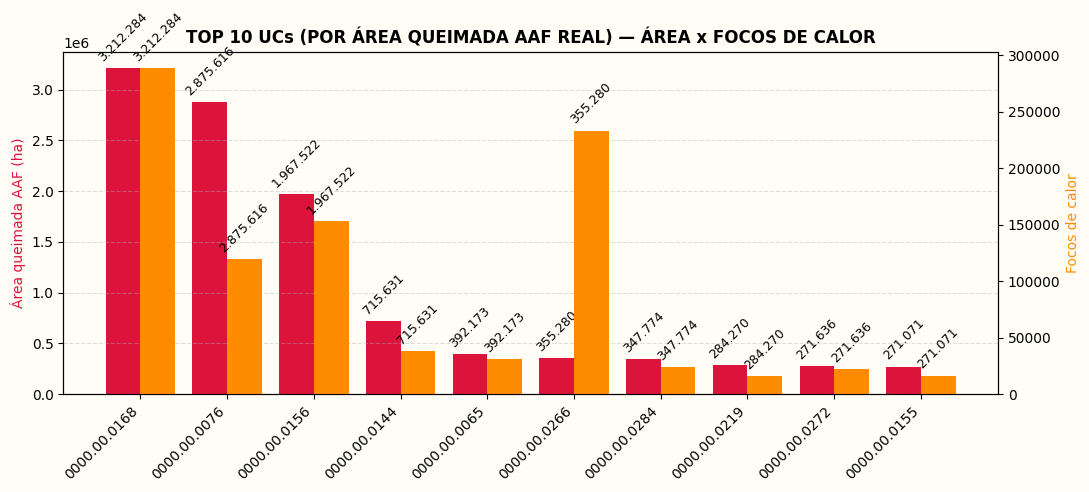

In [150]:
# Top 10 UCs — área queimada real x total de focos de calor

aaf_area_by_uc = gdf_aaf_metric.groupby('cnuc')['area_ha_cell'].sum().rename('aaf_area_ha')
hotspot_count_by_uc = (
    gdf_inpe_with_cell.merge(cell_uc_membership, on='cell_id', how='left')
    .groupby('cnuc').size().rename('hotspot_count')
)

top10_area = (
    pd.concat([aaf_area_by_uc, hotspot_count_by_uc], axis=1)
    .fillna(0)
    .merge(gdf_ucs_metric, on='cnuc', how='left')
    .nlargest(10, 'aaf_area_ha')
)

fig, ax1 = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor('#FFFDF5')
ax1.set_facecolor('#FFFDF5')

x = np.arange(len(top10_area))
width = 0.4

bars1 = ax1.bar(x - width/2, top10_area['aaf_area_ha'], width, color='crimson', label='Área queimada AAF (ha)')
ax1.bar_label(bars1, labels= format_thousands(top10_area['aaf_area_ha']), fontsize=9, rotation=45, padding=3)
ax1.set_ylabel('Área queimada AAF (ha)', color='crimson')
ax1.set_xticks(x)
ax1.set_xticklabels(top10_area['cnuc'], rotation=45, ha='right')
ax1.grid(axis='y', linestyle='--', alpha=0.4)

ax2 = ax1.twinx()
bars2 = ax2.bar(x + width/2, top10_area['hotspot_count'], width, color='darkorange', label='Focos de calor')
ax2.bar_label(bars2, labels=format_thousands(top10_area['aaf_area_ha']), fontsize=9, rotation=45, padding=3)
ax2.set_ylabel('Focos de calor', color='darkorange')

plt.title('TOP 10 UCs (POR ÁREA QUEIMADA AAF REAL) — ÁREA x FOCOS DE CALOR', fontweight='bold')
fig.tight_layout()
plt.show()

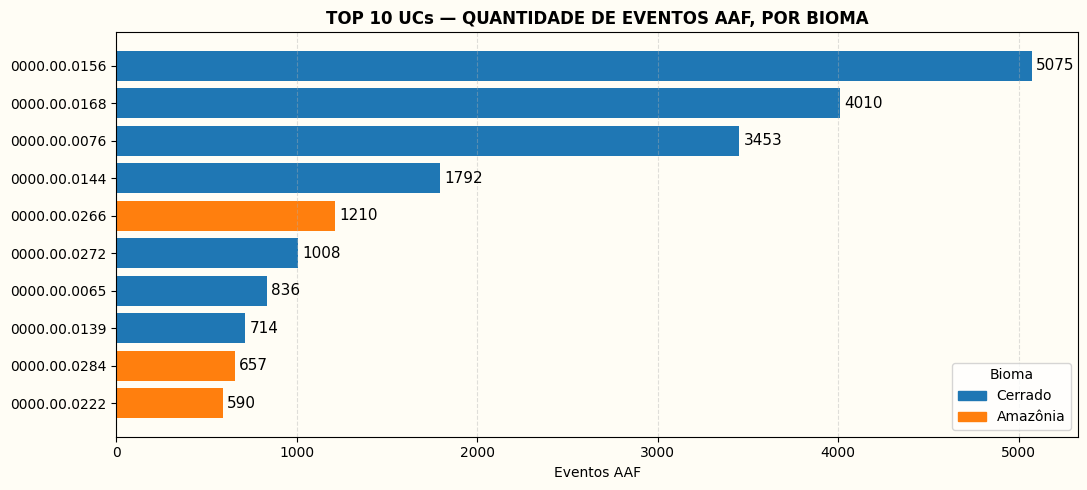

In [151]:
# Top 10 UCs — quantidade de eventos por bioma predominante

uc_info = gdf_ucs_metric[['cnuc', 'nomeuc', 'bioma_pred']].drop_duplicates()

top10_events_bioma = (
    aaf_events_unique.groupby('cnuc').size().rename('n_events')
    .reset_index()
    .merge(uc_info, on='cnuc', how='left')
    .nlargest(10, 'n_events')
)

biomas_unicos = top10_events_bioma['bioma_pred'].unique()
cores_bioma = dict(zip(biomas_unicos, plt.cm.tab10.colors[:len(biomas_unicos)]))
cores_barras = top10_events_bioma['bioma_pred'].map(cores_bioma)

fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor('#FFFDF5')
ax.set_facecolor('#FFFDF5')

bars = ax.barh(top10_events_bioma['cnuc'], top10_events_bioma['n_events'], color=cores_barras)
ax.bar_label(bars, fmt='%.0f', fontsize=11, padding=3)
ax.invert_yaxis()
ax.set_xlabel('Eventos AAF')
ax.set_title('TOP 10 UCs — QUANTIDADE DE EVENTOS AAF, POR BIOMA', fontweight='bold')
ax.grid(axis='x', linestyle='--', alpha=0.4)

legend_handles = [plt.Rectangle((0, 0), 1, 1, color=cor) for cor in cores_bioma.values()]
ax.legend(legend_handles, cores_bioma.keys(), title='Bioma', loc='lower right')

plt.tight_layout()
plt.show()

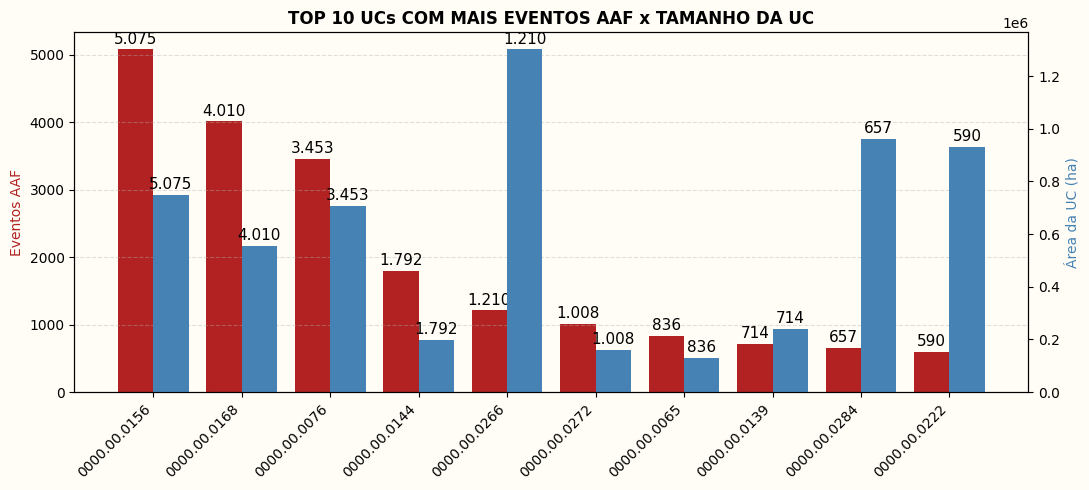

In [152]:
# Top 10 UCs por eventos, comparadas ao tamanho (área total) da UC

top10_events_size = (
    aaf_events_unique.groupby('cnuc').size().rename('n_events')
    .reset_index()
    .merge(gdf_ucs_metric, on='cnuc', how='left')
    .nlargest(10, 'n_events')
)

fig, ax1 = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor('#FFFDF5')
ax1.set_facecolor('#FFFDF5')

x = np.arange(len(top10_events_size))
width = 0.4

bars1 = ax1.bar(x - width/2, top10_events_size['n_events'], width, color='firebrick', label='Eventos AAF')
ax1.bar_label(bars1, labels=format_thousands(top10_events_size['n_events']), fontsize=11, padding=2)
ax1.set_ylabel('Eventos AAF', color='firebrick')
ax1.set_xticks(x)
ax1.set_xticklabels(top10_events_size['cnuc'], rotation=45, ha='right')
ax1.grid(axis='y', linestyle='--', alpha=0.4)

ax2 = ax1.twinx()
bars2 = ax2.bar(x + width/2, top10_events_size['areahaalb'], width, color='steelblue', label='Área da UC (ha)')
ax2.bar_label(bars2, labels=format_thousands(top10_events_size['n_events']), fontsize=11, padding=2)
ax2.set_ylabel('Área da UC (ha)', color='steelblue')

plt.title('TOP 10 UCs COM MAIS EVENTOS AAF x TAMANHO DA UC', fontweight='bold')
fig.tight_layout()
plt.show()

### Temporal — anual, mensal, acumulado

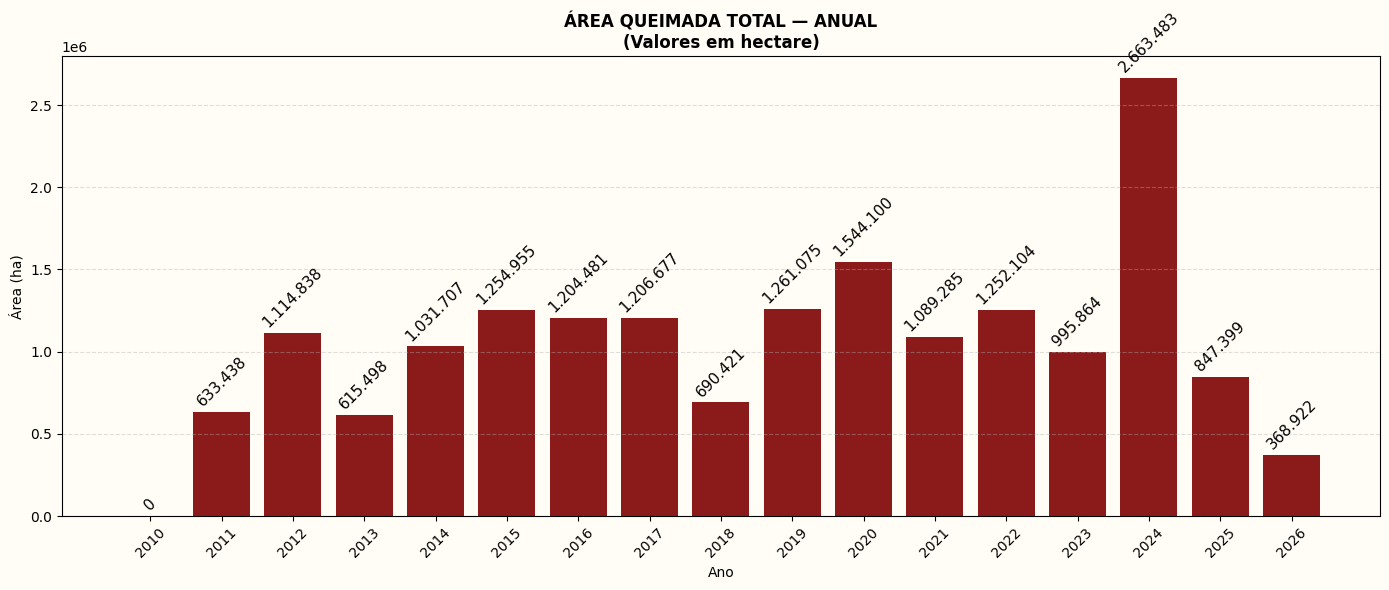

In [153]:
# Área queimada total, por ano

annual_area = gdf_aaf_metric.groupby('event_year')['area_ha_cell'].sum().reindex(range(2010, 2027), fill_value=0)

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#FFFDF5')
ax.set_facecolor('#FFFDF5')

bars = ax.bar(annual_area.index.astype(str), annual_area.values, color='#8b1a1a')
ax.bar_label(bars, labels=format_thousands(annual_area.values), fontsize=11, rotation=45, padding=2)

ax.set_xlabel('Ano')
ax.set_ylabel('Área (ha)')
ax.set_title('ÁREA QUEIMADA TOTAL — ANUAL\n(Valores em hectare)', fontweight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

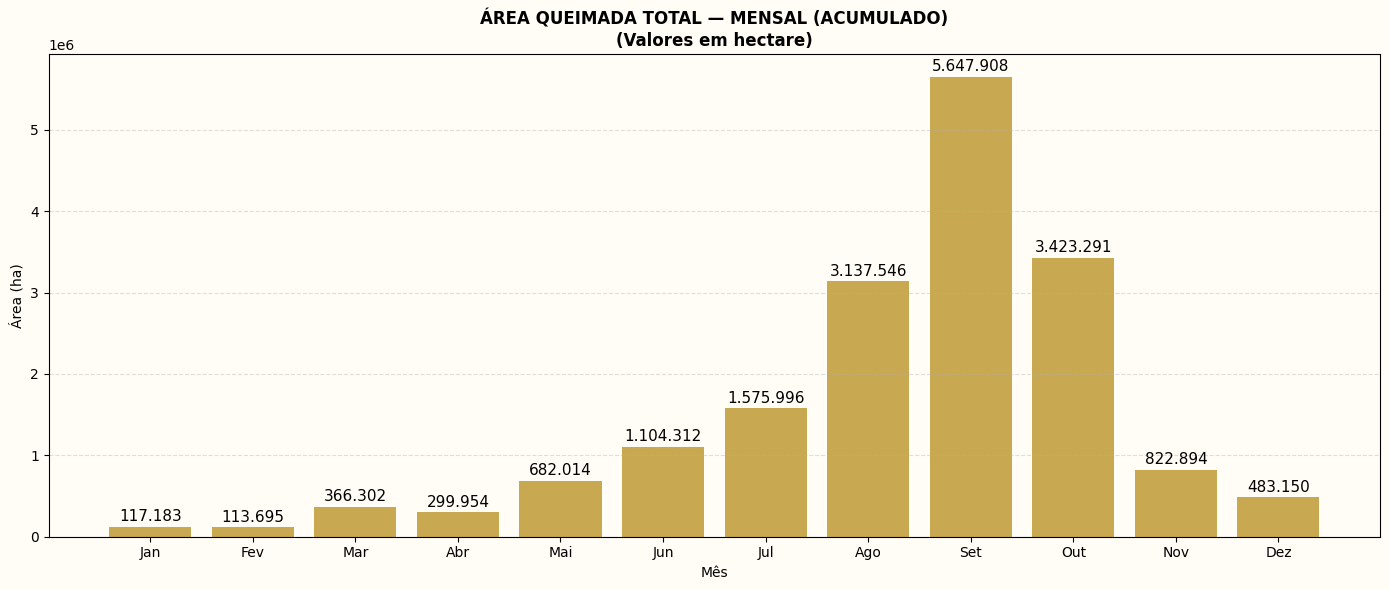

In [154]:
# Área queimada total, por mês (acumulado, todos os anos)

monthly_area = gdf_aaf_metric.groupby('event_month')['area_ha_cell'].sum().reindex(range(1, 13), fill_value=0)

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#FFFDF5')
ax.set_facecolor('#FFFDF5')

bars = ax.bar(months_label, monthly_area.values, color='#c8a951')
ax.bar_label(bars, labels=format_thousands(monthly_area.values), fontsize=11, padding=2)

ax.set_xlabel('Mês')
ax.set_ylabel('Área (ha)')
ax.set_title('ÁREA QUEIMADA TOTAL — MENSAL (ACUMULADO)\n(Valores em hectare)', fontweight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

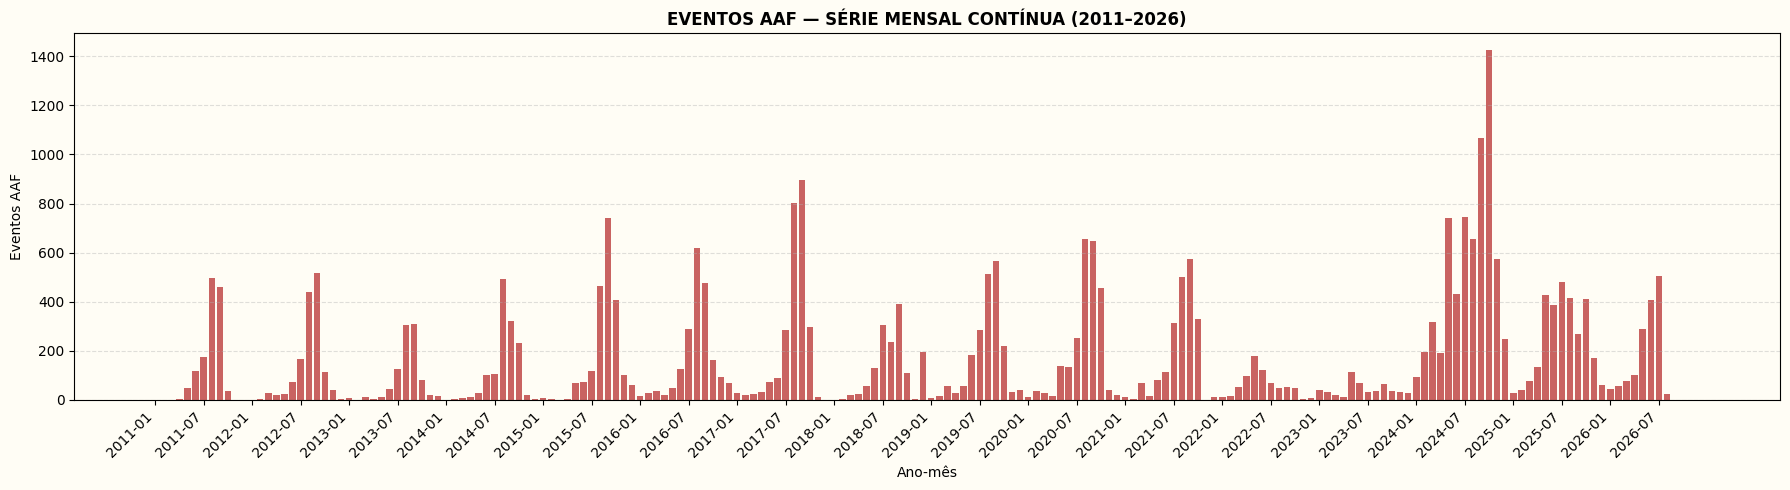

In [155]:
# Série mensal contínua, sem acumular anos (cada ponto = um mês de um ano específico)

min_year = aaf_events_unique['event_year'].min()
max_year = aaf_events_unique['event_year'].max()

aaf_events_unique['year_month'] = pd.to_datetime(
    aaf_events_unique['event_year'].astype(int).astype(str) + '-' +
    aaf_events_unique['event_month'].astype(int).astype(str)
).dt.to_period('M')

events_by_yearmonth = aaf_events_unique.groupby('year_month').size()

full_range = pd.period_range(start=f'{min_year}-01', end=f'{max_year}-12', freq='M')
events_by_yearmonth = events_by_yearmonth.reindex(full_range, fill_value=0)

x_labels = full_range.astype(str)

fig, ax = plt.subplots(figsize=(18, 5))
fig.patch.set_facecolor('#FFFDF5')
ax.set_facecolor('#FFFDF5')

ax.bar(x_labels, events_by_yearmonth.values, color='firebrick', alpha=0.7)
ax.set_xticks(range(0, len(x_labels), 6))
ax.set_xticklabels(x_labels[::6], rotation=45, ha='right')
ax.set_xlabel('Ano-mês')
ax.set_ylabel('Eventos AAF')
ax.set_title(f'EVENTOS AAF — SÉRIE MENSAL CONTÍNUA ({min_year}–{max_year})', fontweight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

### Comparativo AAF x INPE (bioma, temporal)


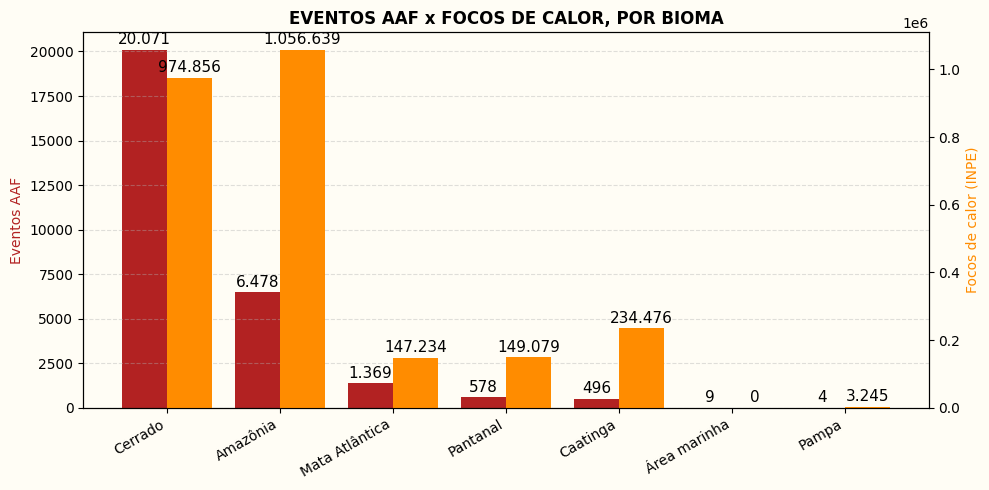

In [156]:
# Eventos AAF x focos INPE, por bioma

uc_bioma = gdf_ucs_metric[['cnuc', 'bioma_pred']].drop_duplicates()

aaf_by_bioma = (
    aaf_events_unique.merge(uc_bioma, on='cnuc', how='left')
    .groupby('bioma_pred').size().rename('aaf_events')
)
inpe_by_bioma = gdf_inpe_with_cell.groupby('bioma', observed=True).size().rename('inpe_hotspots')

biome_comparison = pd.concat([aaf_by_bioma, inpe_by_bioma], axis=1).fillna(0)
biome_comparison = biome_comparison.sort_values('aaf_events', ascending=False)

fig, ax1 = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor("#FFFDF5")
ax1.set_facecolor("#FFFDF5")

x = np.arange(len(biome_comparison))
width = 0.4

bars1 = ax1.bar(x - width/2, biome_comparison['aaf_events'], width, color='firebrick', label='Eventos AAF')
ax1.bar_label(bars1, labels=format_thousands(biome_comparison['aaf_events']), fontsize=11, padding=2)
ax1.set_ylabel('Eventos AAF', color='firebrick')
ax1.set_xticks(x)
ax1.set_xticklabels(biome_comparison.index, rotation=30, ha='right')
ax1.grid(axis='y', linestyle='--', alpha=0.4)

ax2 = ax1.twinx()
bars2 = ax2.bar(x + width/2, biome_comparison['inpe_hotspots'], width, color='darkorange', label='Focos INPE')
ax2.bar_label(bars2, labels=format_thousands(biome_comparison['inpe_hotspots']), fontsize=11, padding=2)
ax2.set_ylabel('Focos de calor (INPE)', color='darkorange')

plt.title('EVENTOS AAF x FOCOS DE CALOR, POR BIOMA', fontweight='bold')
fig.tight_layout()
plt.show()

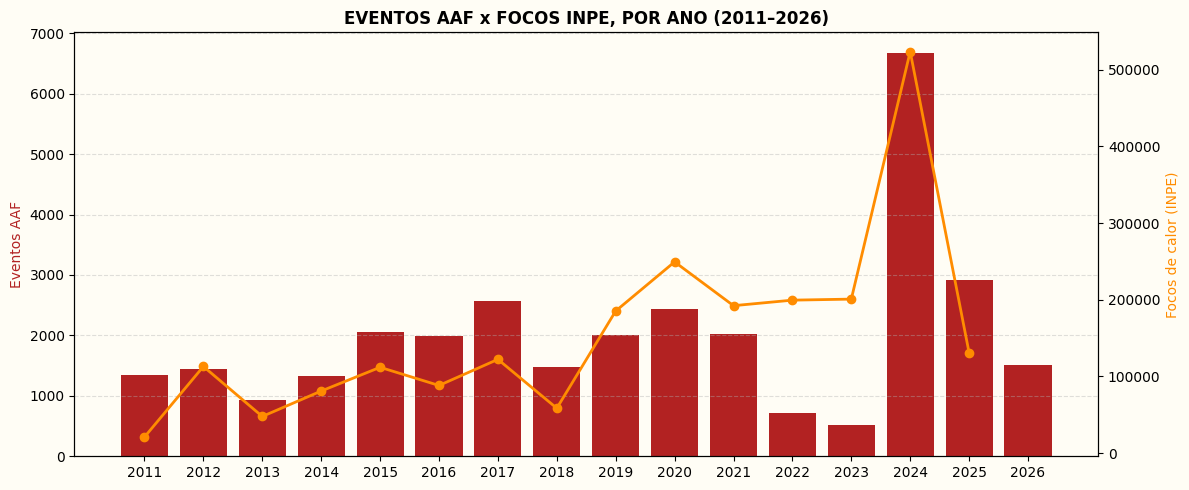

In [157]:
# Eventos AAF x focos INPE, por ano (mesmo intervalo do AAF)

min_year = aaf_events_unique['event_year'].min()
max_year = aaf_events_unique['event_year'].max()

aaf_by_year = aaf_events_unique.groupby('event_year').size()
inpe_by_year = gdf_inpe_with_cell[
    (gdf_inpe_with_cell['file_year'] >= min_year) & (gdf_inpe_with_cell['file_year'] <= max_year)
].groupby('file_year').size()

fig, ax1 = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor("#FFFDF5")
ax1.set_facecolor("#FFFDF5")

ax1.bar(aaf_by_year.index.astype(str), aaf_by_year.values, color='firebrick', label='Eventos AAF')
ax1.set_ylabel('Eventos AAF', color='firebrick')
ax1.grid(axis='y', linestyle='--', alpha=0.4)

ax2 = ax1.twinx()
ax2.plot(aaf_by_year.index.astype(str), inpe_by_year.reindex(aaf_by_year.index).values,
          color='darkorange', marker='o', linewidth=2, label='Focos INPE')
ax2.set_ylabel('Focos de calor (INPE)', color='darkorange')

plt.title(f'EVENTOS AAF x FOCOS INPE, POR ANO ({min_year}–{max_year})', fontweight='bold')
plt.xticks(rotation=45)
fig.tight_layout()
plt.show()


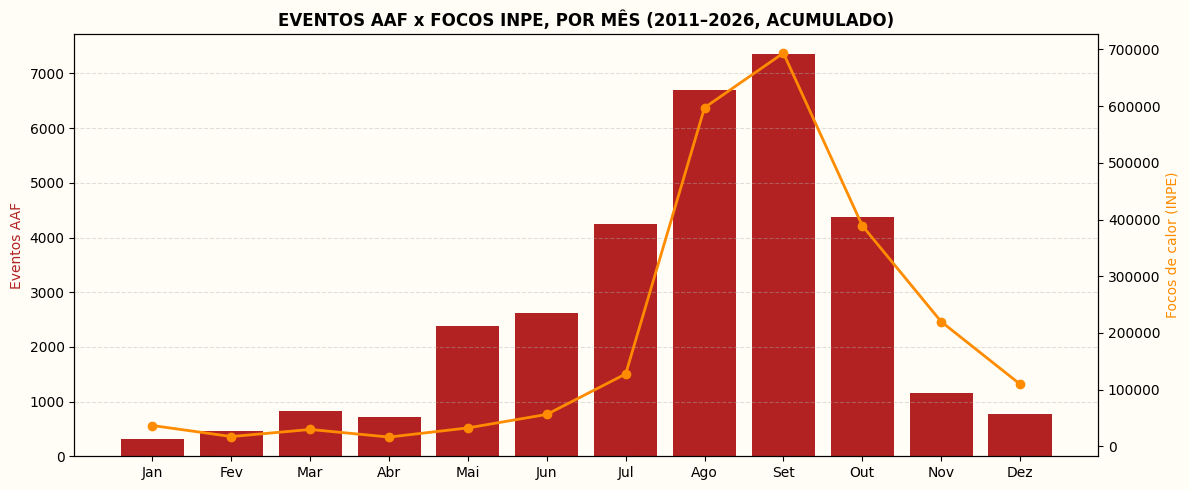

In [158]:
# Eventos AAF x focos INPE, por mês (acumulado, mesmo intervalo do AAF)

aaf_by_month = aaf_events_unique.groupby('event_month').size().reindex(range(1, 13), fill_value=0)

gdf_inpe_with_cell['month'] = pd.to_datetime(gdf_inpe_with_cell['data_pas'], errors='coerce').dt.month
inpe_by_month = gdf_inpe_with_cell[
    (gdf_inpe_with_cell['file_year'] >= min_year) & (gdf_inpe_with_cell['file_year'] <= max_year)
].groupby('month').size().reindex(range(1, 13), fill_value=0)

fig, ax1 = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor("#FFFDF5")
ax1.set_facecolor("#FFFDF5")

ax1.bar(months_label, aaf_by_month.values, color='firebrick', label='Eventos AAF')
ax1.set_ylabel('Eventos AAF', color='firebrick')
ax1.grid(axis='y', linestyle='--', alpha=0.4)

ax2 = ax1.twinx()
ax2.plot(months_label, inpe_by_month.values, color='darkorange', marker='o', linewidth=2, label='Focos INPE')
ax2.set_ylabel('Focos de calor (INPE)', color='darkorange')

plt.title(f'EVENTOS AAF x FOCOS INPE, POR MÊS ({min_year}–{max_year}, ACUMULADO)', fontweight='bold')
fig.tight_layout()
plt.show()

### Tipo de evento harmonizado (contagem, área, FRP, espacial)


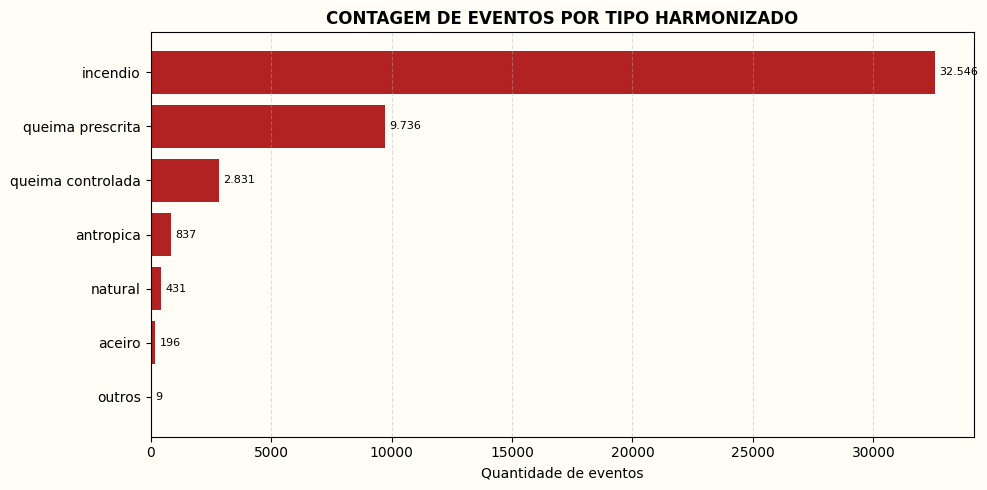

In [159]:
# Contagem de eventos por tipo

event_type_counts = gdf_aaf_metric.dropna(subset=['event_type'])['event_type'].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor("#FFFDF5")
ax.set_facecolor("#FFFDF5")

bars = ax.barh(event_type_counts.index, event_type_counts.values, color='firebrick')
ax.bar_label(bars, labels=format_thousands(event_type_counts.values), fontsize=8, padding=3)
ax.invert_yaxis()
ax.set_xlabel('Quantidade de eventos')
ax.set_title('CONTAGEM DE EVENTOS POR TIPO HARMONIZADO', fontweight='bold')
ax.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [180]:
# FRP médio associado a cada tipo harmonizado (vínculo aproximado: mesma célula + ano + mês)

frp_by_cell_period = (
    gdf_inpe_with_cell.groupby(['cell_id', 'file_year', 'month'])['frp']
    .mean()
    .rename('frp_mean_period')
    .reset_index()
)

aaf_with_frp = gdf_aaf_metric.dropna(subset=['event_type']).merge(
    frp_by_cell_period,
    left_on=['cell_id', 'file_year', 'event_month'],
    right_on=['cell_id', 'file_year', 'month'],
    how='inner'
)

aaf_with_frp['event_type'].value_counts()

event_type
incendio             25664
queima prescrita      5301
queima controlada     1948
antropica              619
natural                359
aceiro                  88
outros                   8
Name: count, dtype: int64

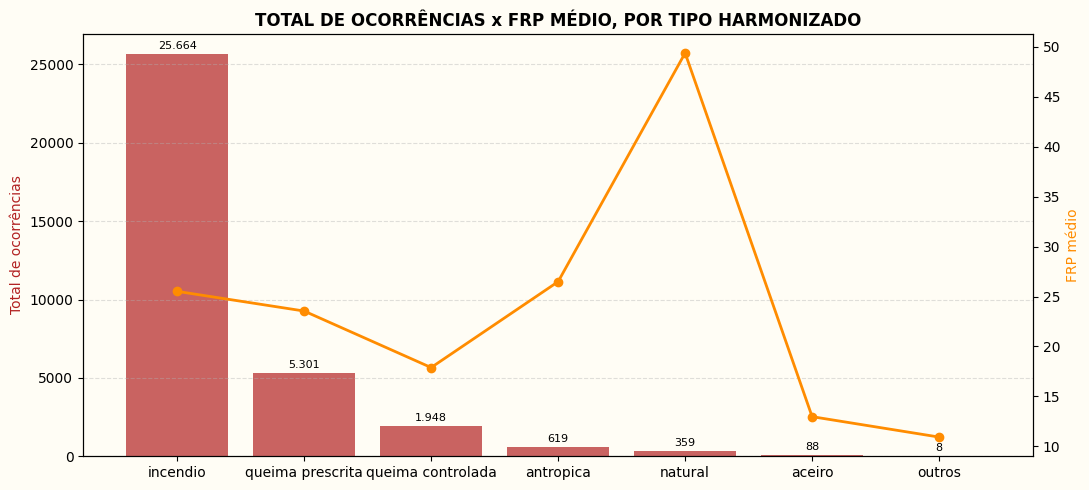

In [181]:
# Total de ocorrências por tipo x FRP médio, por tipo harmonizado

occurrence_by_type = aaf_with_frp['event_type'].value_counts()
frp_mean_by_type = aaf_with_frp.groupby('event_type')['frp_mean_period'].mean()

combo_df = pd.concat([occurrence_by_type.rename('n_events'), frp_mean_by_type.rename('frp_mean')], axis=1)
combo_df = combo_df.sort_values('n_events', ascending=False)

fig, ax1 = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor("#FFFDF5")
ax1.set_facecolor("#FFFDF5")

bars = ax1.bar(combo_df.index, combo_df['n_events'], color='firebrick', alpha=0.7, label='Ocorrências')
ax1.bar_label(bars, labels=format_thousands(combo_df['n_events']), fontsize=8, padding=2)
ax1.set_ylabel('Total de ocorrências', color='firebrick')
ax1.grid(axis='y', linestyle='--', alpha=0.4)

ax2 = ax1.twinx()
ax2.plot(combo_df.index, combo_df['frp_mean'], color='darkorange', marker='o', linewidth=2, label='FRP médio')
ax2.set_ylabel('FRP médio', color='darkorange')

plt.title('TOTAL DE OCORRÊNCIAS x FRP MÉDIO, POR TIPO HARMONIZADO', fontweight='bold')
plt.xticks(rotation=30, ha='right')
fig.tight_layout()
plt.show()


### Regime do Fogo

Total de células na grade: 82045
Células que nunca queimaram (sem nenhum evento AAF): 75384
Células que queimaram em apenas 1 ano distinto (FRI não calculável): 2448
Células com FRI calculável (2+ anos distintos com evento): 4213


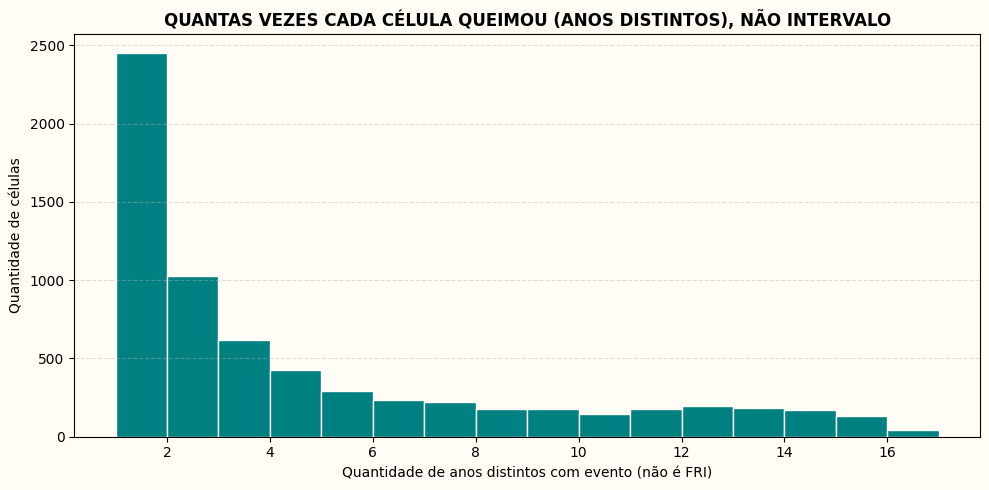

In [ ]:
# Frequência (FRI) — intervalo médio de retorno, por célula (AAF)

total_cells = len(gdf_grid)
cells_that_burned = gdf_aaf_metric['cell_id'].nunique()
cells_never_burned = total_cells - cells_that_burned

fire_years_by_cell = gdf_aaf_metric.groupby('cell_id')['event_year'].nunique()

cells_burned_once = (fire_years_by_cell == 1).sum()
cells_fri_calculable = (fire_years_by_cell >= 2).sum()

print(f"Total de células na grade: {total_cells}")
print(f"Células que nunca queimaram (sem nenhum evento AAF): {cells_never_burned}")
print(f"Células que queimaram em apenas 1 ano distinto (FRI não calculável): {cells_burned_once}")
print(f"Células com FRI calculável (2+ anos distintos com evento): {cells_fri_calculable}")

# Distribuição de QUANTAS VEZES (anos distintos) cada célula queimou — métrica diferente do FRI
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor("#FFFDF5")
ax.set_facecolor("#FFFDF5")

ax.hist(fire_years_by_cell, bins=range(1, 18), color='teal', edgecolor='white')
ax.set_xlabel('Quantidade de anos distintos com evento (não é FRI)')
ax.set_ylabel('Quantidade de células')
ax.set_title('QUANTAS VEZES CADA CÉLULA QUEIMOU (ANOS DISTINTOS), NÃO INTERVALO', fontweight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

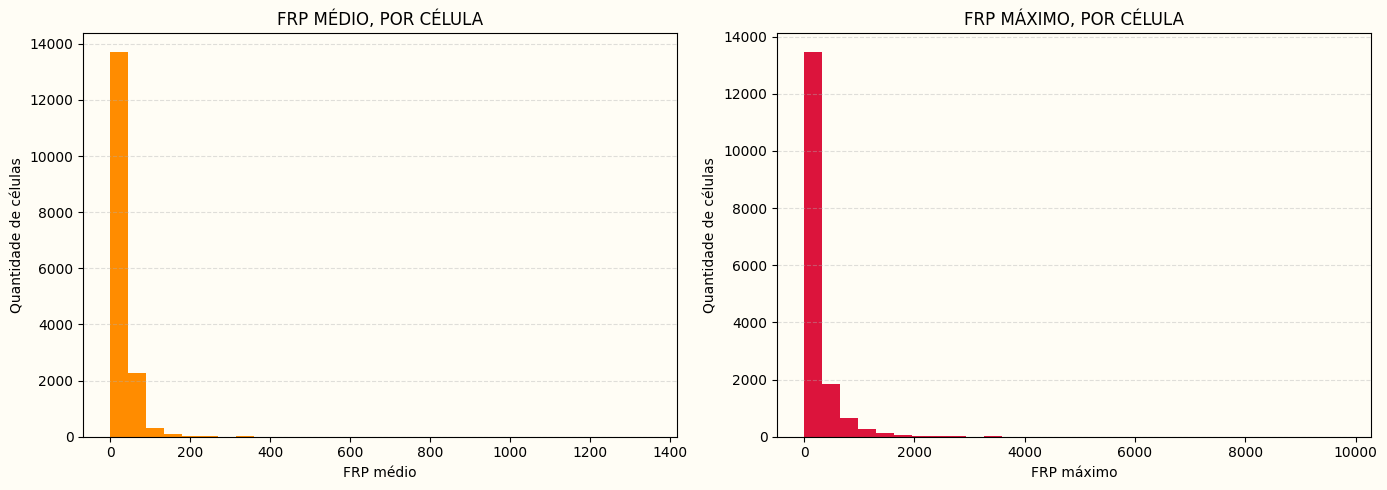

In [200]:
# Intensidade (FRP) — médio e máximo, por célula (INPE)

frp_by_cell = gdf_inpe_with_cell.groupby('cell_id')['frp'].agg(frp_mean='mean', frp_max='max').dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#FFFDF5')

axes[0].set_facecolor('#FFFDF5')
axes[0].hist(frp_by_cell['frp_mean'], bins=30, color='darkorange')
axes[0].set_xlabel('FRP médio')
axes[0].set_ylabel('Quantidade de células')
axes[0].set_title('FRP MÉDIO, POR CÉLULA')
axes[0].grid(axis='y', linestyle='--', alpha=0.4)

axes[1].set_facecolor('#FFFDF5')
axes[1].hist(frp_by_cell['frp_max'], bins=30, color='crimson')
axes[1].set_xlabel('FRP máximo')
axes[1].set_ylabel('Quantidade de células')
axes[1].set_title('FRP MÁXIMO, POR CÉLULA')
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [201]:
frp_by_cell

,frp_mean,frp_max
cell_id,,
100_504,22.715837,225.899994
100_505,19.121304,158.100006
100_506,18.585430,124.199997
100_507,20.746462,110.199997
100_508,21.874561,262.299988
...,...,...
99_540,4.200000,4.200000
9_576,20.133333,33.099998
9_577,27.827999,159.500000


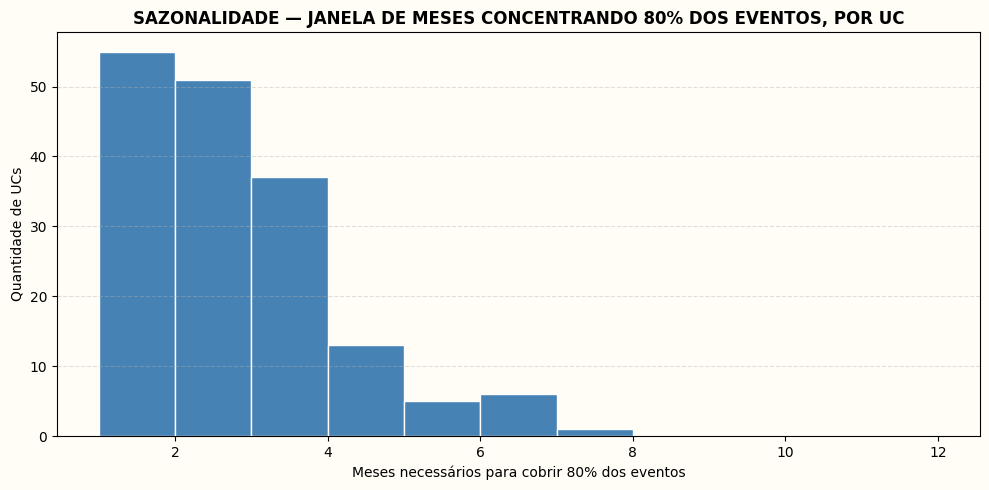

In [202]:
#  Sazonalidade — janela de meses concentrando 80% dos eventos, por UC

def seasonal_window(months, coverage=0.8):
    # ordena meses pela frequência, acumula até atingir a cobertura desejada, retorna quantos meses foram necessários
    counts = months.value_counts().sort_values(ascending=False)
    cumulative = counts.cumsum() / counts.sum()
    return (cumulative <= coverage).sum() + 1

seasonal_by_uc = (
    gdf_aaf_metric.dropna(subset=['cnuc'])
    .groupby('cnuc')['event_month']
    .apply(lambda x: seasonal_window(x, 0.8))
    .rename('n_months_80pct')
)

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#FFFDF5')
ax.set_facecolor('#FFFDF5')

ax.hist(seasonal_by_uc, bins=range(1, 13), color='steelblue', edgecolor='white')
ax.set_xlabel('Meses necessários para cobrir 80% dos eventos')
ax.set_ylabel('Quantidade de UCs')
ax.set_title('SAZONALIDADE — JANELA DE MESES CONCENTRANDO 80% DOS EVENTOS, POR UC', fontweight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

C:\Users\ANDERSONALVESCOELHO\AppData\Local\Temp\ipykernel_52544\2663107088.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(data_by_type, labels=gdf_aaf_metric['event_type'].dropna().unique(), showfliers=False)


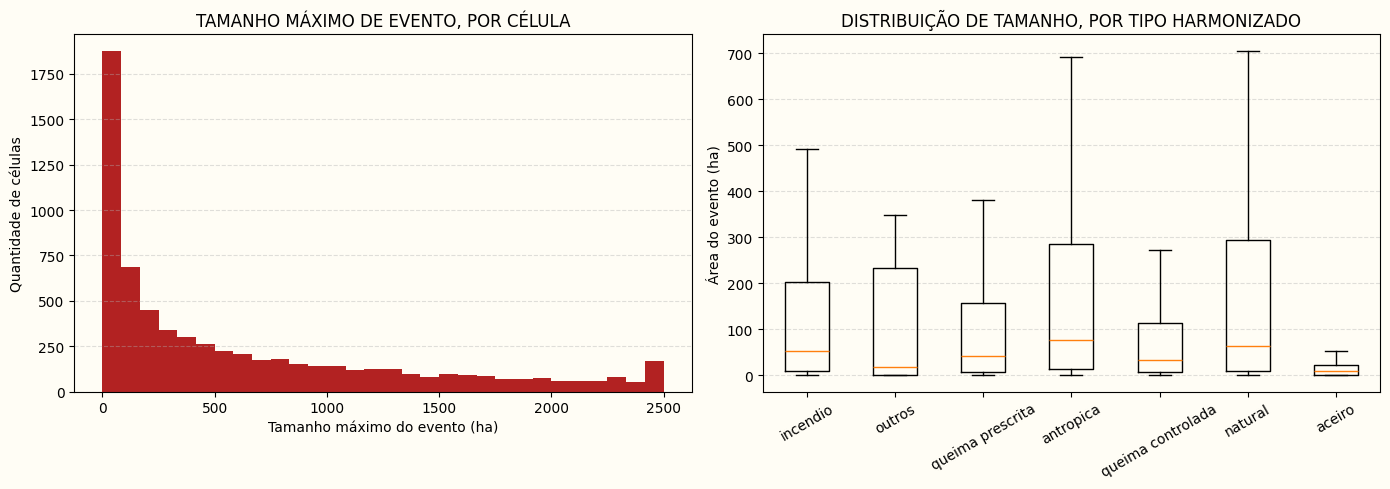

In [203]:
# Tamanho — máximo por célula, e distribuição por tipo de evento harmonizado

# %%
max_size_by_cell = gdf_aaf_metric.groupby('cell_id')['area_ha_cell'].max()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#FFFDF5')

axes[0].set_facecolor('#FFFDF5')
axes[0].hist(max_size_by_cell, bins=30, color='firebrick')
axes[0].set_xlabel('Tamanho máximo do evento (ha)')
axes[0].set_ylabel('Quantidade de células')
axes[0].set_title('TAMANHO MÁXIMO DE EVENTO, POR CÉLULA')
axes[0].grid(axis='y', linestyle='--', alpha=0.4)

axes[1].set_facecolor('#FFFDF5')
data_by_type = [
    gdf_aaf_metric[gdf_aaf_metric['event_type'] == t]['area_ha_cell'].dropna()
    for t in gdf_aaf_metric['event_type'].dropna().unique()
]
axes[1].boxplot(data_by_type, labels=gdf_aaf_metric['event_type'].dropna().unique(), showfliers=False)
axes[1].set_ylabel('Área do evento (ha)')
axes[1].set_title('DISTRIBUIÇÃO DE TAMANHO, POR TIPO HARMONIZADO')
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

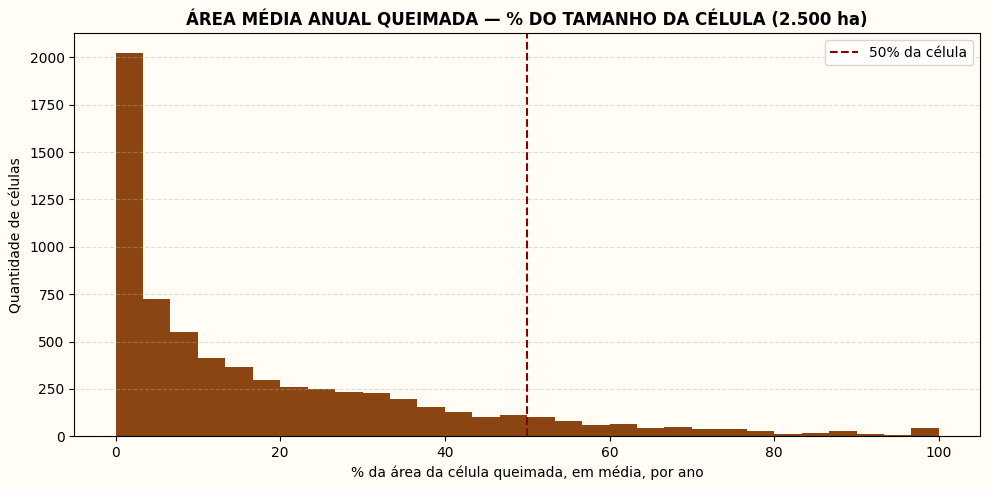

Células que queimam, em média, mais de 50% de sua área todo ano: 621


In [206]:
# Área média anual queimada — por célula, comparada ao tamanho da célula (2.500 ha)

# %%
CELL_AREA_HA = 2500  # 5km x 5km

annual_area_by_cell = gdf_aaf_metric.groupby(['cell_id', 'event_year'])['area_ha_cell'].sum().reset_index()
mean_annual_area_by_cell = annual_area_by_cell.groupby('cell_id')['area_ha_cell'].mean()
pct_of_cell_burned = (mean_annual_area_by_cell / CELL_AREA_HA * 100).clip(upper=100)

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#FFFDF5')
ax.set_facecolor('#FFFDF5')

ax.hist(pct_of_cell_burned, bins=30, color='saddlebrown')
ax.axvline(50, color='darkred', linestyle='--', label='50% da célula')
ax.set_xlabel('% da área da célula queimada, em média, por ano')
ax.set_ylabel('Quantidade de células')
ax.set_title('ÁREA MÉDIA ANUAL QUEIMADA — % DO TAMANHO DA CÉLULA (2.500 ha)', fontweight='bold')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print("Células que queimam, em média, mais de 50% de sua área todo ano:", (pct_of_cell_burned > 50).sum())


In [ ]:
# Limpeza de memória

del (
    aaf_area_by_uc,
    hotspot_count_by_uc,
    top10_area,
    uc_info,
    top10_events_bioma,
    biomas_unicos,
    cores_bioma,
    cores_barras,
    top10_events_size,
    annual_area,
    monthly_area,
    events_by_yearmonth,
    full_range,
    x_labels,
    uc_bioma,
    aaf_by_bioma,
    inpe_by_bioma,
    biome_comparison,
    aaf_by_year,
    inpe_by_year,
    aaf_by_month,
    inpe_by_month,
    event_type_counts,
    frp_by_cell_period,
    aaf_with_frp,
    frp_by_cell_period,
    aaf_with_frp,
    occurrence_by_type,
    frp_mean_by_type,
    combo_df,
    years_by_cell,
    years_by_cell,
    fri_by_cell,
    frp_by_cell,
    seasonal_by_uc,
    max_size_by_cell,
    data_by_type,
    annual_area_by_cell,
    mean_annual_area_by_cell,
    pct_of_cell_burned,
)
gc.collect()

# Pré-processamento


# Modelagem / treinamento


# Avaliação do modelo


# Ajuste de hiperparâmetros


# Validação final
